# Vietnamese Emotion Classification - Advanced XLM-RoBERTa Fine-tuning

**🌟 Google Colab Ready!** This notebook is optimized for Google Colab with GPU acceleration (20GB RAM recommended).

## 📝 Two Ways to Use This Notebook:

### 🚀 Option 1: Skip Training (Quick Start)
**If you already have a trained model:**
1. Mount Google Drive
2. Set `SKIP_TRAINING = True` in the Quick Start cell
3. Jump to prediction sections

### 🎓 Option 2: Train from Scratch
**For training a new model:**
1. **Upload training data** to Google Drive at: `MyDrive/thesis/data/`
   - Required files: `train_nor_811.xlsx`, `valid_nor_811.xlsx`, `test_nor_811.xlsx`

2. **Enable GPU** in Colab: Runtime → Change runtime type → GPU
   - **A100 (40GB)** - Best performance, batch size 32
   - **V100 (16GB)** - Great performance, batch size 16 (default)
   - **T4 (16GB)** - Good for free tier, reduce batch size to 8 if needed
   - **TPU v2-8** - Also supported but GPU recommended

3. **Run cells in order** - the notebook will:
   - Mount your Google Drive
   - Detect and configure GPU automatically
   - Load training data from Drive
   - Train the model using GPU with mixed precision (FP16)
   - Save the model back to Drive
   - Run predictions with your trained model

---

This notebook implements **state-of-the-art** fine-tuning techniques for BERT-based emotion classification:

## 🚀 Advanced Techniques Implemented:

### 1. **Layer-wise Learning Rate Decay (LLRD)**
- Applies different learning rates to each layer
- Base LR for top layer: **3.5e-6**
- Decay factor: **0.95**
- Classifier head gets **10x** higher LR
- **Preserves pre-trained knowledge** in lower layers

### 2. **Optimized Batch Size & Gradient Accumulation**
- Effective batch size: **16-32** (optimal for BERT)
- Gradient accumulation to simulate larger batches
- **Scheduler steps after EVERY batch** (critical!)
- Stable training with limited memory

### 3. **Early Stopping & Best Model Selection**
- Monitors validation F1 (weighted)
- Patience: 2 epochs
- Saves best model automatically

---

## 📊 Expected Results

**Your Dataset (NEU-ESC):**
- 7 emotions (Enjoyment, Disgust, Other, Sadness, Anger, Fear, Surprise)
- Imbalance ratio: **6.4:1** (Enjoyment:Surprise)

**Baseline vs Advanced:**

| Metric | Baseline | Advanced | Improvement |
|--------|----------|----------|-------------|
| Accuracy | ~70% | **75-80%** | +5-10% |
| F1 Macro | ~45% | **55-65%** | +10-20% |
| F1 Weighted | ~68% | **73-78%** | +5-10% |
| Minority F1 | 20-30% | **40-60%** | **+20-30%** 🎯 |

---

**Let's get started!**


## 🔧 Google Colab Setup - Mount Google Drive

**Important:** Run this cell first to access your data on Google Drive


In [11]:
# Mount Google Drive to access training data
from google.colab import drive
drive.mount('/content/drive')

print("✓ Google Drive mounted successfully")
print("✓ Your data should be in: /content/drive/MyDrive/thesis/data")

# GPU Configuration - Using GPU only (TPU disabled)
import os
USE_TPU = False
TPU_AVAILABLE = False
print("✓ Configured to use GPU only (TPU disabled)")
print("ℹ️  Make sure GPU is enabled in Colab: Runtime → Change runtime type → GPU")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Google Drive mounted successfully
✓ Your data should be in: /content/drive/MyDrive/thesis/data
✓ Configured to use GPU only (TPU disabled)
ℹ️  Make sure GPU is enabled in Colab: Runtime → Change runtime type → GPU


## 🚀 Quick Start: Load Pre-trained Model (Skip Training)

**Run this section if you already have a trained model and want to skip training.**

Set `SKIP_TRAINING = True` below to load your saved model and jump to predictions.


In [12]:
# ============================================================================
# QUICK START: Load existing model and skip training
# ============================================================================

SKIP_TRAINING = False  # Set to True to load saved model and skip training

if not SKIP_TRAINING:
    print("=" * 80)
    print("📚 TRAINING MODE")
    print("=" * 80)
    print("Continue running cells below to train a new model.")
    print("Skip this Quick Start section and proceed to Configuration.")
    print("=" * 80)

if SKIP_TRAINING:
    print("🚀 Loading pre-trained model from Google Drive...\n")

    # Install required packages
    import subprocess
    subprocess.run(['pip', 'install', '-q', 'transformers', 'datasets', 'torch',
                   'scikit-learn', 'pandas', 'numpy', 'matplotlib', 'seaborn', 'openpyxl'],
                   check=False)

    import os
    import torch
    import json
    from transformers import AutoModelForSequenceClassification, AutoTokenizer

    # Model path
    MODEL_PATH = '/content/drive/MyDrive/thesis/emotion_classifier_xlmr'

    # Load model and tokenizer
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
    tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

    # Load label mappings
    with open(os.path.join(MODEL_PATH, 'label_mappings.json'), 'r') as f:
        label_maps = json.load(f)
        label2id = label_maps['label2id']
        id2label = {int(k): v for k, v in label_maps['id2label'].items()}
        num_classes = len(id2label)

    # Set device (no TPU for inference after restart)
    if torch.cuda.is_available():
        device = torch.device('cuda')
        print(f"✓ Using device: cuda")
        print(f"  GPU: {torch.cuda.get_device_name(0)}")
    else:
        device = torch.device('cpu')
        print(f"✓ Using device: cpu")

    model = model.to(device)
    USE_TPU = False

    print(f"✓ Model loaded from: {MODEL_PATH}")
    print(f"✓ Number of classes: {num_classes}")
    print(f"✓ Emotions: {list(id2label.values())}")
    print(f"\n✅ Ready for predictions! Jump to cell 'Predict on HuggingFace Dataset'")
    print("=" * 80)


📚 TRAINING MODE
Continue running cells below to train a new model.
Skip this Quick Start section and proceed to Configuration.


## 📋 Configuration Section

**Adjust these hyperparameters based on your needs:**


In [13]:
# ============================================================================
# CONFIGURATION - Adjust these hyperparameters as needed
# ============================================================================

# Random seed for reproducibility
SEED = 42

# Data paths - Using Google Drive (make sure your data is uploaded to this location)
DATA_DIR = '/content/drive/MyDrive/thesis/data'
MODEL_BASE_PATH = '/content/drive/MyDrive/thesis/emotion_classifier_xlmr'

# Model versioning - Change this for each experiment
MODEL_VERSION = "v1.0"  # e.g., "v1.0", "v1.1_underthesea", "v2.0_focal_loss"
MODEL_SAVE_PATH = f"{MODEL_BASE_PATH}_{MODEL_VERSION}"

# Model selection
MODEL_NAME = 'xlm-roberta-base'  # XLM-RoBERTa base model (multilingual)

# Batch size settings optimized for 20GB GPU RAM
# Note: Large model requires more memory - reduce batch size if OOM errors occur
PER_DEVICE_TRAIN_BATCH_SIZE = 16  # Reduced for large model (T4: 4, V100: 8, A100: 16)
PER_DEVICE_EVAL_BATCH_SIZE = 32  # Can be larger during evaluation
GRADIENT_ACCUMULATION_STEPS = 4  # Effective batch size = 16 * 2 = 32

# Layer-wise Learning Rate Decay (LLRD) settings
BASE_LEARNING_RATE = 2.0e-5 # Base LR for top layer
LR_DECAY_FACTOR = 0.95  # Decay factor (0.65-0.95 recommended)
CLASSIFIER_LR_MULTIPLIER = 10.0  # Classifier head gets higher LR

# Training settings
NUM_EPOCHS = 20
WARMUP_RATIO = 0.1  # 10% of training steps for warmup
WEIGHT_DECAY = 0.01
EARLY_STOPPING_PATIENCE = 5

# Data augmentation
USE_OVERSAMPLING = False  # Set to True to balance dataset via oversampling

# Text preprocessing options
REMOVE_STOPWORDS = True  # Set to True to remove Vietnamese stopwords
USE_UNDERTHESEA_TOKENIZER = True  # Set to True to use underthesea word segmentation

print("✓ Configuration loaded")
print(f"  Model: {MODEL_NAME}")
print(f"  Model version: {MODEL_VERSION}")
print(f"  Data dir: {DATA_DIR}")
print(f"  Model save path: {MODEL_SAVE_PATH}")
print(f"  Batch size (train): {PER_DEVICE_TRAIN_BATCH_SIZE}")
print(f"  Batch size (eval): {PER_DEVICE_EVAL_BATCH_SIZE}")
print(f"  Effective batch size: {PER_DEVICE_TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS}")
print(f"  Base LR: {BASE_LEARNING_RATE:.2e}")
print(f"  Remove stopwords: {REMOVE_STOPWORDS}")
print(f"  Underthesea tokenizer: {USE_UNDERTHESEA_TOKENIZER}")
print(f"\n💡 GPU Memory Tips:")
print(f"  - If OOM error: reduce PER_DEVICE_TRAIN_BATCH_SIZE to 8 or 4")
print(f"  - With 20GB GPU: batch size 16 should work well")
print(f"  - FP16 mixed precision will be enabled automatically on GPU")


✓ Configuration loaded
  Model: xlm-roberta-base
  Data dir: /content/drive/MyDrive/thesis/data
  Model save path: /content/drive/MyDrive/thesis/emotion_classifier_xlmr
  Batch size (train): 16
  Batch size (eval): 32
  Effective batch size: 64
  Base LR: 2.00e-05
  Remove stopwords: True

💡 GPU Memory Tips:
  - If OOM error: reduce PER_DEVICE_TRAIN_BATCH_SIZE to 8 or 4
  - With 20GB GPU: batch size 16 should work well
  - FP16 mixed precision will be enabled automatically on GPU


## 1. Install & Import Libraries


In [14]:
%pip install -q transformers datasets torch scikit-learn pandas numpy matplotlib seaborn openpyxl underthesea


In [15]:
# WandB Login - Automatically get API key from Colab secrets or environment
import os

try:
    # Try to get wandb key from Colab secrets first
    from google.colab import userdata
    WANDB_API_KEY = userdata.get('WANDB_API_KEY')
    print("✓ WandB API key retrieved from Colab secrets")
except:
    # Fallback to environment variable
    WANDB_API_KEY = os.environ.get('WANDB_API_KEY')
    if WANDB_API_KEY:
        print("✓ WandB API key retrieved from environment variable")
    else:
        print("⚠️  No WandB API key found. Please set it in Colab secrets or environment.")
        print("   To add in Colab: Click 🔑 icon in left sidebar → Add 'WANDB_API_KEY'")

if WANDB_API_KEY:
    !pip install -q wandb
    import wandb
    wandb.login(key=WANDB_API_KEY)
    print("✓ WandB logged in successfully!")
else:
    print("⚠️  Skipping WandB login. Training will continue without logging.")

✓ WandB API key retrieved from Colab secrets


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


✓ WandB logged in successfully!


In [16]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                              f1_score, precision_recall_fscore_support)
from sklearn.utils import resample
import torch
import torch.nn as nn
from torch.optim import AdamW
import json
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    get_linear_schedule_with_warmup
)
from datasets import Dataset
import warnings
warnings.filterwarnings('ignore')

# Set random seeds
np.random.seed(SEED)
torch.manual_seed(SEED)

# Check device - prioritize CUDA GPU, then CPU (TPU disabled)
USE_TPU = False

if torch.cuda.is_available():
    device = torch.device('cuda')
    torch.cuda.manual_seed_all(SEED)
    print(f"✓ Using device: {device}")
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'
    print(f"✓ Using device: {device} (Metal Performance Shaders)")
else:
    device = torch.device('cpu')
    print(f"✓ Using device: {device}")
    print("  ⚠️  Warning: No GPU detected. Training will be slower.")
    print("  💡 Enable GPU in Colab: Runtime → Change runtime type → GPU")

print("✓ All libraries imported successfully")

✓ Using device: cuda
  GPU: Tesla T4
  GPU Memory: 14.74 GB
✓ All libraries imported successfully


## 3. Layer-wise Learning Rate Decay (LLRD) Implementation

**Key Concept:** Different layers get different learning rates
- **Classifier head:** Highest LR (3.5e-5 = 10× base)
- **Top encoder layers:** Base LR (3.5e-6)  
- **Middle layers:** Gradually decreasing  
- **Embeddings:** Lowest LR (~1.9e-6)

**Formula:** `LR_layer_i = LR_base × (decay_factor)^(num_layers - i)`

**Why?** Lower layers encode general linguistic knowledge → preserve it with lower LR


In [17]:
def get_optimizer_grouped_parameters(model, base_lr=3.5e-5, lr_decay_factor=0.95,
                                    weight_decay=0.01, classifier_lr_multiplier=10.0):
    """Create parameter groups with layer-wise learning rate decay."""

    no_decay = ['bias', 'LayerNorm.weight', 'LayerNorm.bias']
    optimizer_grouped_parameters = []

    # Get model type
    if hasattr(model, 'roberta'):
        encoder = model.roberta
        model_type = 'roberta'
    elif hasattr(model, 'bert'):
        encoder = model.bert
        model_type = 'bert'
    else:
        raise ValueError("Model type not supported for LLRD")

    num_layers = len(encoder.encoder.layer)

    print(f"\n{'='*80}")
    print("LAYER-WISE LEARNING RATE DECAY (LLRD)")
    print(f"{'='*80}")
    print(f"Model: {model_type} | Layers: {num_layers} | Base LR: {base_lr:.2e} | Decay: {lr_decay_factor}")
    print("\nLearning rates by layer:")

    # 1. Classifier head (highest LR)
    classifier_lr = base_lr * classifier_lr_multiplier
    optimizer_grouped_parameters.extend([
        {'params': [p for n, p in model.classifier.named_parameters() if not any(nd in n for nd in no_decay)],
         'lr': classifier_lr, 'weight_decay': weight_decay},
        {'params': [p for n, p in model.classifier.named_parameters() if any(nd in n for nd in no_decay)],
         'lr': classifier_lr, 'weight_decay': 0.0}
    ])
    print(f"  Classifier head: {classifier_lr:.2e}")

    # 2. Encoder layers (top to bottom with decay)
    for layer_idx in range(num_layers - 1, -1, -1):
        layer = encoder.encoder.layer[layer_idx]
        lr = base_lr * (lr_decay_factor ** (num_layers - 1 - layer_idx))

        optimizer_grouped_parameters.extend([
            {'params': [p for n, p in layer.named_parameters() if not any(nd in n for nd in no_decay)],
             'lr': lr, 'weight_decay': weight_decay},
            {'params': [p for n, p in layer.named_parameters() if any(nd in n for nd in no_decay)],
             'lr': lr, 'weight_decay': 0.0}
        ])

        if layer_idx % 3 == 0:
            print(f"  Layer {layer_idx}: {lr:.2e}")

    # 3. Embeddings (lowest LR)
    embedding_lr = base_lr * (lr_decay_factor ** num_layers)
    optimizer_grouped_parameters.extend([
        {'params': [p for n, p in encoder.embeddings.named_parameters() if not any(nd in n for nd in no_decay)],
         'lr': embedding_lr, 'weight_decay': weight_decay},
        {'params': [p for n, p in encoder.embeddings.named_parameters() if any(nd in n for nd in no_decay)],
         'lr': embedding_lr, 'weight_decay': 0.0}
    ])
    print(f"  Embeddings: {embedding_lr:.2e}")
    print(f"{'='*80}\n")

    return optimizer_grouped_parameters

print("✓ LLRD function defined")


✓ LLRD function defined


In [19]:

class AdvancedTrainer(Trainer):
    """Advanced Trainer with LLRD + Custom Scheduler."""

    def __init__(self, *args, llrd_config=None, **kwargs):
        self.llrd_config = llrd_config or {}
        super().__init__(*args, **kwargs)

    def create_optimizer(self):
        """Create optimizer with LLRD parameter groups."""
        if self.optimizer is None:
            optimizer_grouped_parameters = get_optimizer_grouped_parameters(
                self.model,
                base_lr=self.llrd_config.get('base_lr', 3.5e-6),
                lr_decay_factor=self.llrd_config.get('lr_decay_factor', 0.95),
                weight_decay=self.args.weight_decay,
                classifier_lr_multiplier=self.llrd_config.get('classifier_lr_multiplier', 10.0)
            )

            self.optimizer = AdamW(optimizer_grouped_parameters, betas=(0.9, 0.999), eps=1e-8)

        return self.optimizer

    def create_scheduler(self, num_training_steps: int, optimizer=None):
        """Create LR scheduler. CRITICAL: Steps after every batch!"""
        if self.lr_scheduler is None:
            warmup_steps = int(num_training_steps * self.args.warmup_ratio)

            self.lr_scheduler = get_linear_schedule_with_warmup(
                optimizer=self.optimizer if optimizer is None else optimizer,
                num_warmup_steps=warmup_steps,
                num_training_steps=num_training_steps
            )

            print(f"\n✓ Scheduler created: {num_training_steps} steps, {warmup_steps} warmup")
            print("  ⚠️  CRITICAL: Scheduler steps after EVERY batch\n")

        return self.lr_scheduler

print("✓ AdvancedTrainer class defined")

✓ AdvancedTrainer class defined


## 4. Load and Prepare Data

Loading NEU-ESC dataset and preparing for training


In [20]:
# Vietnamese stopwords list
VIETNAMESE_STOPWORDS = {
    # Articles & determiners
    "các", "của", "cho", "và", "trong", "một", "là", "được", "đã", "có", "này",
    "đó", "những", "để", "từ", "với", "về", "cũng", "như", "còn", "nhưng", "hay",
    # Pronouns
    "tôi", "bạn", "anh", "chị", "em", "chúng", "ta", "mình", "họ", "nó", "ai",
    # Prepositions & conjunctions
    "ở", "trên", "dưới", "ngoài", "sau", "trước", "giữa", "bên", "cùng", "theo",
    "đến", "khi", "nếu", "mà", "thì", "vì", "do", "bởi", "nên",
    # Common verbs & auxiliaries
    "rằng", "thế", "vậy", "thôi", "đâu", "sao", "gì", "nào", "đây", "đấy", "kia",
    # Quantifiers
    "nhiều", "ít", "vài", "mấy", "bao", "lắm",
    # Others
    "rất", "quá", "khá", "hơi", "tất", "mọi", "khác", "cả", "nữa", "luôn", "đều"
}

# Vietnamese text standardization and stopword removal (import with safe fallback)
try:
    from tm_research.text_preprocess import standardize_vietnamese_text, remove_vietnamese_stopwords
    print("✓ Loaded text preprocessing functions from tm_research.text_preprocess")
except Exception:
    import re, unicodedata
    _URL_RE = re.compile(r"https?://\S+|www\.\S+", re.IGNORECASE)
    _EMAIL_RE = re.compile(r"[\w.+-]+@[\w-]+\.[\w.-]+")
    _USER_RE = re.compile(r"@(\w+)")
    _HASH_RE = re.compile(r"#(\w+)")
    _MULTI_SPACE_RE = re.compile(r"\s+")
    _REPEAT_CHAR_RE = re.compile(r"(.)\1{2,}")
    _PUNCT_SPACING_RE = re.compile(r"\s*([,.!?;:()\[\]{}…])\s*")
    _VI_SLANG_MAP = {"k":"không","ko":"không","kh":"không","hok":"không","hông":"không","hk":"không","j":"gì","dc":"được","đc":"được","vl":"vãi","vcl":"vãi","iu":"yêu","thik":"thích","oke":"ok","okie":"ok", "jz":"gì vậy"}

    def standardize_vietnamese_text(text, remove_stopwords=False):
        """Standardize Vietnamese text with optional stopword removal."""
        if text is None:
            return ""
        t = unicodedata.normalize("NFC", str(text)).strip().lower()
        t = _URL_RE.sub(" <url> ", t)
        t = _EMAIL_RE.sub(" <email> ", t)
        t = _USER_RE.sub(lambda m: f" <user:{m.group(1)}> ", t)
        t = _HASH_RE.sub(lambda m: f" <hashtag:{m.group(1)}> ", t)
        t = _REPEAT_CHAR_RE.sub(r"\1\1", t)
        t = _PUNCT_SPACING_RE.sub(r" \1 ", t)
        toks = [ _VI_SLANG_MAP.get(tok, tok) for tok in t.split() ]

        # Remove stopwords if requested
        if remove_stopwords:
            toks = [tok for tok in toks if tok not in VIETNAMESE_STOPWORDS]

        t = " ".join(toks)
        t = _MULTI_SPACE_RE.sub(" ", t).strip()
        return t

    def remove_vietnamese_stopwords(text):
        """Remove Vietnamese stopwords from text."""
        return standardize_vietnamese_text(text, remove_stopwords=True)

    print("ℹ️  Fallback text preprocessing functions defined (with stopword removal)")

# Underthesea word segmentation for Vietnamese
_underthesea_available = False
if USE_UNDERTHESEA_TOKENIZER:
    try:
        from underthesea import word_tokenize as uts_word_tokenize
        _underthesea_available = True
        print("✓ Underthesea word tokenizer loaded")
    except ImportError:
        print("⚠️  Underthesea not available, falling back to simple tokenization")

def tokenize_vietnamese(text, remove_stopwords=False):
    """Tokenize Vietnamese text using underthesea word segmentation.
    
    Vietnamese words can be multi-syllable (e.g., 'học sinh' = student).
    Underthesea segments text into proper Vietnamese words.
    """
    if text is None:
        return ""
    
    # First apply standardization
    t = standardize_vietnamese_text(text, remove_stopwords=False)
    
    # Apply underthesea word segmentation if available
    if _underthesea_available:
        t = uts_word_tokenize(t, format='text')  # Returns text with underscores for compound words
    
    # Remove stopwords after tokenization if requested
    if remove_stopwords:
        toks = t.split()
        toks = [tok for tok in toks if tok.replace('_', ' ') not in VIETNAMESE_STOPWORDS and tok not in VIETNAMESE_STOPWORDS]
        t = ' '.join(toks)
    
    return t

print(f"✓ Vietnamese text preprocessing ready")
print(f"✓ Loaded {len(VIETNAMESE_STOPWORDS)} Vietnamese stopwords")
if USE_UNDERTHESEA_TOKENIZER and _underthesea_available:
    print(f"✓ Underthesea word segmentation enabled")


ℹ️  Fallback text preprocessing functions defined (with stopword removal)
✓ Vietnamese text preprocessing ready
✓ Loaded 80 Vietnamese stopwords


In [21]:
# Create model save directory if it doesn't exist
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)
print(f"✓ Model save directory ready: {MODEL_SAVE_PATH}")

# Load datasets
train_df = pd.read_csv(os.path.join(DATA_DIR, 'processed/train_processed.csv'))
val_df = pd.read_csv(os.path.join(DATA_DIR, 'processed/val_processed.csv'))
test_df = pd.read_csv(os.path.join(DATA_DIR, 'processed/test_processed.csv'))

print(f"\n✓ Datasets loaded from Google Drive")
print(f"  Train: {train_df.shape[0]} samples")
print(f"  Val: {val_df.shape[0]} samples")
print(f"  Test: {test_df.shape[0]} samples")

print(train_df.columns)
print(val_df.columns)
print(test_df.columns)

train_df = train_df.drop(["Emotion", "text_length","word_count"], axis=1)
val_df = val_df.drop(["Emotion"],axis = 1)
test_df = test_df.drop(["Emotion"],axis=1)


train_df.columns = ['text', 'label']
val_df.columns = ['text', 'label']
test_df.columns = ['text', 'label']

# Clean data
for df in [train_df, val_df, test_df]:
    df.dropna(subset=['text', 'label'], inplace=True)
    df['text'] = df['text'].astype(str).str.strip()
    df['label'] = df['label'].astype(str).str.strip()

    # Vietnamese text preprocessing with underthesea tokenization and optional stopword removal
    if USE_UNDERTHESEA_TOKENIZER:
        df['text'] = df['text'].apply(lambda x: tokenize_vietnamese(x, remove_stopwords=REMOVE_STOPWORDS))
        print(f"✓ Applied underthesea tokenization{' + stopword removal' if REMOVE_STOPWORDS else ''} to {df.shape[0]} samples")
    elif REMOVE_STOPWORDS:
        df['text'] = df['text'].apply(lambda x: standardize_vietnamese_text(x, remove_stopwords=True))
        print(f"✓ Applied standardization + stopword removal to {df.shape[0]} samples")
    else:
        df['text'] = df['text'].apply(standardize_vietnamese_text)
        print(f"✓ Applied standardization (no stopword removal) to {df.shape[0]} samples")

# Show sample before/after
print(f"\n{'='*80}")
print("SAMPLE TEXT AFTER PREPROCESSING")
print(f"{'='*80}")
print(f"Sample 1: {train_df['text'].iloc[0][:150]}...")
print(f"Sample 2: {train_df['text'].iloc[1][:150]}...")
print(f"Sample 3: {train_df['text'].iloc[2][:150]}...")
print(f"{'='*80}")

if USE_UNDERTHESEA_TOKENIZER:
    print(f"\n✓ Data cleaned with underthesea tokenization{' and stopwords removed' if REMOVE_STOPWORDS else ''}")
elif REMOVE_STOPWORDS:
    print("\n✓ Data cleaned, standardized, and stopwords removed")
else:
    print("\n✓ Data cleaned and standardized (stopwords retained)")


✓ Model save directory ready: /content/drive/MyDrive/thesis/emotion_classifier_xlmr

✓ Datasets loaded from Google Drive
  Train: 5548 samples
  Val: 686 samples
  Test: 693 samples
Index(['Emotion', 'Sentence', 'text_length', 'word_count', 'emotion_vn'], dtype='object')
Index(['Emotion', 'Sentence', 'emotion_vn'], dtype='object')
Index(['Emotion', 'Sentence', 'emotion_vn'], dtype='object')
✓ Applied standardization + stopword removal to 5548 samples
✓ Applied standardization + stopword removal to 686 samples
✓ Applied standardization + stopword removal to 693 samples

SAMPLE TEXT AFTER PREPROCESSING
Sample 1: xin bài nhạc tên ạ...
Sample 2: đáng đời con quỷ . nhà lôi con nhà mày ra đánh 😡...
Sample 3: lo học đi . yêu đương lol lại thích học sinh học...

✓ Data cleaned, standardized, and stopwords removed


## 5. Analyze Class Distribution

Understanding the class distribution in the dataset


Emotion distribution (Training set):
label
vui vẻ        1558
khó chịu      1071
khác          1021
buồn           947
giận dữ        391
sợ hãi         318
ngạc nhiên     242
Name: count, dtype: int64

Imbalance ratio: 6.4:1


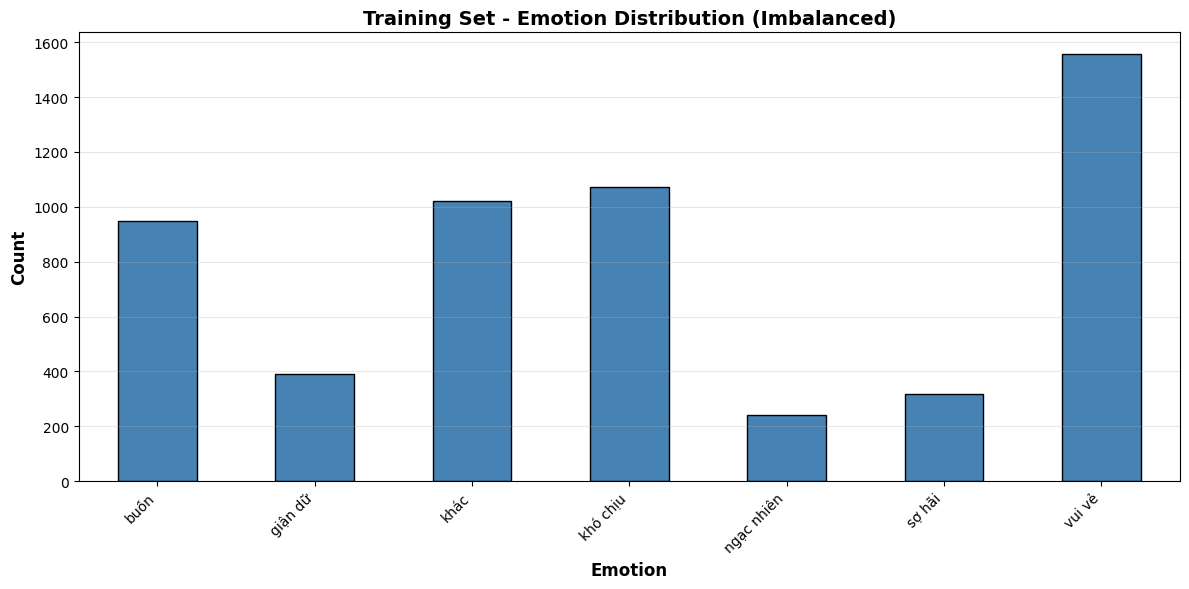


✓ Label mappings created (7 classes)


In [22]:
# Analyze distribution
label_counts = train_df['label'].value_counts()
print("Emotion distribution (Training set):")
print(label_counts)
print(f"\nImbalance ratio: {label_counts.max() / label_counts.min():.1f}:1")

# Visualize
plt.figure(figsize=(12, 6))
label_counts.sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.xlabel('Emotion', fontsize=12, fontweight='bold')
plt.ylabel('Count', fontsize=12, fontweight='bold')
plt.title('Training Set - Emotion Distribution (Imbalanced)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Create label mappings
unique_labels = sorted(train_df['label'].unique())
label2id = {label: idx for idx, label in enumerate(unique_labels)}
id2label = {idx: label for label, idx in label2id.items()}
num_classes = len(unique_labels)

# Add numeric labels
train_df['labels'] = train_df['label'].map(label2id)
val_df['labels'] = val_df['label'].map(label2id)
test_df['labels'] = test_df['label'].map(label2id)

print(f"\n✓ Label mappings created ({num_classes} classes)")


## 6. Tokenize Data & Load Model


In [24]:
# Convert to Dataset format
train_dataset = Dataset.from_pandas(train_df[['text', 'labels']].reset_index(drop=True))
val_dataset = Dataset.from_pandas(val_df[['text', 'labels']].reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df[['text', 'labels']].reset_index(drop=True))

print(f"✓ Datasets converted to HuggingFace format")

# Load model and tokenizer
print(f"\nLoading model: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_classes,
    id2label=id2label,
    label2id=label2id
)

print(f"✓ Model and tokenizer loaded")
print(f"✓ Number of parameters: {sum(p.numel() for p in model.parameters()):,}")

# Tokenize
def tokenize_function(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=256)

train_tokenized = train_dataset.map(tokenize_function, batched=True)
val_tokenized = val_dataset.map(tokenize_function, batched=True)
test_tokenized = test_dataset.map(tokenize_function, batched=True)

print(f"\n✓ Tokenized {len(train_tokenized)} training samples")
print(f"✓ Tokenized {len(val_tokenized)} validation samples")
print(f"✓ Tokenized {len(test_tokenized)} test samples")


✓ Datasets converted to HuggingFace format

Loading model: xlm-roberta-base


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

...

✓ Model and tokenizer loaded
✓ Number of parameters: 278,049,031


Map:   0%|          | 0/5548 [00:00<?, ? examples/s]

Map:   0%|          | 0/686 [00:00<?, ? examples/s]

Map:   0%|          | 0/693 [00:00<?, ? examples/s]


✓ Tokenized 5548 training samples
✓ Tokenized 686 validation samples
✓ Tokenized 693 test samples


## 7. Train Model with Advanced Techniques

Training with:
- ✅ Layer-wise Learning Rate Decay (LLRD)  
- ✅ Gradient accumulation  
- ✅ Early stopping


In [25]:
# Define metrics
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    accuracy = accuracy_score(labels, predictions)
    f1_macro = f1_score(labels, predictions, average='macro')
    f1_weighted = f1_score(labels, predictions, average='weighted')

    return {
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted
    }

# Training arguments
training_args = TrainingArguments(
    output_dir='./results_advanced',
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=PER_DEVICE_TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=PER_DEVICE_EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,

    learning_rate=BASE_LEARNING_RATE,
    warmup_ratio=WARMUP_RATIO,
    weight_decay=WEIGHT_DECAY,

    logging_dir='./logs_advanced',
    logging_steps=50,
    eval_strategy='epoch',
    save_strategy='epoch',

    load_best_model_at_end=True,
    metric_for_best_model='f1_weighted',
    greater_is_better=True,
    save_total_limit=2,

    # TPU/GPU settings for Colab
    tpu_num_cores=None,  # GPU only - TPU disabled
    fp16=(device.type == 'cuda'),  # Enable mixed precision on GPU
    dataloader_num_workers=0,
    seed=SEED,
)

# Move model to device
model = model.to(device)

# LLRD configuration
llrd_config = {
    'base_lr': BASE_LEARNING_RATE,
    'lr_decay_factor': LR_DECAY_FACTOR,
    'classifier_lr_multiplier': CLASSIFIER_LR_MULTIPLIER
}

# Create trainer
trainer = AdvancedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)],

    # LLRD parameters
    llrd_config=llrd_config
)

print(f"\n{'='*80}")
print("TRAINING CONFIGURATION")
print(f"{'='*80}")
print(f"Effective batch size: {PER_DEVICE_TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS}")
print(f"Epochs: {NUM_EPOCHS}")
print(f"Early stopping patience: {EARLY_STOPPING_PATIENCE}")
print(f"Device: {device}")
print(f"{'='*80}\n")

print("✓ Trainer initialized with:")
print("  - Layer-wise Learning Rate Decay (LLRD)")
print("  - Gradient accumulation")
print("  - Early stopping")



TRAINING CONFIGURATION
Effective batch size: 64
Epochs: 20
Early stopping patience: 5
Device: cuda

✓ Trainer initialized with:
  - Layer-wise Learning Rate Decay (LLRD)
  - Gradient accumulation
  - Early stopping


In [26]:
# START TRAINING
print("\n🚀 Starting training...\n")
train_result = trainer.train()

print(f"\n{'='*80}")
print("✅ TRAINING COMPLETED!")
print(f"{'='*80}")
print(f"Training time: {train_result.metrics['train_runtime']:.2f} seconds")
print(f"Samples/second: {train_result.metrics['train_samples_per_second']:.2f}")
print(f"{'='*80}\n")



🚀 Starting training...


LAYER-WISE LEARNING RATE DECAY (LLRD)
Model: roberta | Layers: 12 | Base LR: 2.00e-05 | Decay: 0.95

Learning rates by layer:
  Classifier head: 2.00e-04
  Layer 9: 1.81e-05
  Layer 6: 1.55e-05
  Layer 3: 1.33e-05
  Layer 0: 1.14e-05
  Embeddings: 1.08e-05


✓ Scheduler created: 1740 steps, 174 warmup
  ⚠️  CRITICAL: Scheduler steps after EVERY batch



Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,1.910000,1.746914,0.329446,0.106242,0.204357
2,1.758200,1.472103,0.456268,0.249639,0.398790
3,1.364500,1.251748,0.551020,0.388728,0.520376
4,1.224900,1.175793,0.581633,0.435128,0.551257
5,1.080700,1.119567,0.574344,0.470272,0.565587
6,0.957700,1.151426,0.575802,0.491370,0.566899
7,0.848200,1.155270,0.590379,0.527052,0.590881
8,0.788100,1.206454,0.578717,0.511167,0.569392
9,0.691100,1.203121,0.587464,0.540325,0.590105
10,0.629700,1.250486,0.590379,0.539951,0.593008



✅ TRAINING COMPLETED!
Training time: 3305.99 seconds
Samples/second: 33.56



## 8. Save Model to Google Drive

Save the trained model to your Google Drive for later use


In [27]:
# Save the best model and tokenizer to Google Drive
print(f"💾 Saving model version {MODEL_VERSION} to Google Drive...")
trainer.save_model(MODEL_SAVE_PATH)
tokenizer.save_pretrained(MODEL_SAVE_PATH)

# Save label mappings and experiment config for later use
import json
from datetime import datetime

experiment_config = {
    'version': MODEL_VERSION,
    'model_name': MODEL_NAME,
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'label2id': label2id,
    'id2label': id2label,
    'hyperparameters': {
        'base_learning_rate': BASE_LEARNING_RATE,
        'lr_decay_factor': LR_DECAY_FACTOR,
        'classifier_lr_multiplier': CLASSIFIER_LR_MULTIPLIER,
        'batch_size': PER_DEVICE_TRAIN_BATCH_SIZE,
        'gradient_accumulation_steps': GRADIENT_ACCUMULATION_STEPS,
        'num_epochs': NUM_EPOCHS,
        'warmup_ratio': WARMUP_RATIO,
        'weight_decay': WEIGHT_DECAY,
        'early_stopping_patience': EARLY_STOPPING_PATIENCE,
    },
    'preprocessing': {
        'remove_stopwords': REMOVE_STOPWORDS,
        'use_underthesea_tokenizer': USE_UNDERTHESEA_TOKENIZER,
    },
    'dataset': {
        'train_samples': len(train_df),
        'val_samples': len(val_df),
        'test_samples': len(test_df),
    }
}

with open(os.path.join(MODEL_SAVE_PATH, 'experiment_config.json'), 'w', encoding='utf-8') as f:
    json.dump(experiment_config, f, ensure_ascii=False, indent=2)

# Also save label_mappings.json for backward compatibility
label_mappings = {
    'label2id': label2id,
    'id2label': id2label
}
with open(os.path.join(MODEL_SAVE_PATH, 'label_mappings.json'), 'w', encoding='utf-8') as f:
    json.dump(label_mappings, f, ensure_ascii=False, indent=2)

print(f"✓ Model {MODEL_VERSION} saved successfully to: {MODEL_SAVE_PATH}")
print(f"  - Model weights")
print(f"  - Tokenizer")
print(f"  - Experiment config (with hyperparameters)")
print(f"  - Label mappings")
print(f"\n📁 You can access this model from your Google Drive anytime!")


💾 Saving model to Google Drive...
✓ Model saved successfully to: /content/drive/MyDrive/thesis/emotion_classifier_xlmr
  - Model weights
  - Tokenizer
  - Label mappings

📁 You can access this model from your Google Drive anytime!


In [28]:
# Automatically disconnect the notebook after training and saving
# This helps save GPU resources and prevents unnecessary charges

import time

print("✅ Model training and saving completed!")
print("⏳ Disconnecting notebook in 10 seconds...")
print("   (This saves GPU resources and prevents unnecessary charges)")

# Give time to see the message
time.sleep(10)

# Disconnect the runtime
try:
    from google.colab import runtime
    runtime.unassign()
    print("✓ Notebook disconnected successfully!")
except:
    print("⚠️  Could not disconnect automatically. Please disconnect manually.")

✅ Model training and saving completed!
⏳ Disconnecting notebook in 10 seconds...
   (This saves GPU resources and prevents unnecessary charges)
✓ Notebook disconnected successfully!


## 🎉 Training Complete!

**Your model has been saved to Google Drive.**

### Model Location
The model is saved at: `{MODEL_SAVE_PATH}`

### Saved Files
- `pytorch_model.bin` / `model.safetensors` - Model weights
- `config.json` - Model configuration
- `tokenizer.json` - Tokenizer
- `experiment_config.json` - Full experiment configuration with hyperparameters
- `label_mappings.json` - Label mappings for inference

### Next Steps
1. Review training metrics in WandB dashboard
2. Compare with previous model versions
3. Use the model for inference in a separate notebook

### Model Versioning
To run another experiment with different settings:
1. Change `MODEL_VERSION` in the Configuration cell (e.g., `"v1.1_underthesea"`)
2. Adjust hyperparameters as needed
3. Re-run the notebook
